# 223. Rectangle Area
https://leetcode.com/problems/rectangle-area/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Math (overlap calculation) | $O(1)$ | $O(1)$ | Optimal |

## Methodology

Compute the total area as the sum of both rectangles minus the overlap area. The overlap in x is `max(0, min(C,G) - max(A,E))` and in y is `max(0, min(D,H) - max(B,F))`. The overlap area is the product of these two values. Total = area1 + area2 - overlap.

## Solutions

### C#

In [ ]:
public class Solution {
    public int ComputeArea(int ax1, int ay1, int ax2, int ay2, int bx1, int by1, int bx2, int by2) {
        int area1 = (ax2 - ax1) * (ay2 - ay1);
        int area2 = (bx2 - bx1) * (by2 - by1);
        int overlapX = Math.Max(0, Math.Min(ax2, bx2) - Math.Max(ax1, bx1));
        int overlapY = Math.Max(0, Math.Min(ay2, by2) - Math.Max(ay1, by1));
        return area1 + area2 - overlapX * overlapY;
    }
}

### Python

In [ ]:
class Solution:
    def computeArea(self, ax1: int, ay1: int, ax2: int, ay2: int,
                    bx1: int, by1: int, bx2: int, by2: int) -> int:
        area1 = (ax2 - ax1) * (ay2 - ay1)
        area2 = (bx2 - bx1) * (by2 - by1)
        overlap_x = max(0, min(ax2, bx2) - max(ax1, bx1))
        overlap_y = max(0, min(ay2, by2) - max(ay1, by1))
        return area1 + area2 - overlap_x * overlap_y

### Go

In [ ]:
func computeArea(ax1 int, ay1 int, ax2 int, ay2 int, bx1 int, by1 int, bx2 int, by2 int) int {
    area1 := (ax2 - ax1) * (ay2 - ay1)
    area2 := (bx2 - bx1) * (by2 - by1)
    overlapX := max(0, min(ax2, bx2)-max(ax1, bx1))
    overlapY := max(0, min(ay2, by2)-max(ay1, by1))
    return area1 + area2 - overlapX*overlapY
}

### Rust

In [ ]:
impl Solution {
    pub fn compute_area(ax1: i32, ay1: i32, ax2: i32, ay2: i32,
                        bx1: i32, by1: i32, bx2: i32, by2: i32) -> i32 {
        let area1 = (ax2 - ax1) * (ay2 - ay1);
        let area2 = (bx2 - bx1) * (by2 - by1);
        let overlap_x = 0.max(ax2.min(bx2) - ax1.max(bx1));
        let overlap_y = 0.max(ay2.min(by2) - ay1.max(by1));
        area1 + area2 - overlap_x * overlap_y
    }
}

## Example Scenarios

### 1. Common Case — Partial Overlap
**Input:** `ax1=-3, ay1=0, ax2=3, ay2=4, bx1=0, by1=-1, bx2=9, by2=2`

Rectangle A has area $6 \times 4 = 24$. Rectangle B has area $9 \times 3 = 27$. Overlap in x: $\min(3,9) - \max(-3,0) = 3$. Overlap in y: $\min(4,2) - \max(0,-1) = 2$. Overlap area $= 3 \times 2 = 6$.

WHY tricky: The overlap computation requires **clamping to 0** with $\max(0, \ldots)$ to handle the case where rectangles don't overlap in one dimension.

$\text{Total} = 24 + 27 - 6 = 45$. **Output:** `45`

---

### 2. Slightly Complex — One Rectangle Inside Another
**Input:** `ax1=0, ay1=0, ax2=4, ay2=4, bx1=1, by1=1, bx2=3, by2=3`

B is entirely inside A. Overlap equals B's entire area = $2 \times 2 = 4$. Total $= 16 + 4 - 4 = 16$. The covered area equals the larger rectangle's area.

WHY tricky: The formula still works when one rectangle is **fully contained** — the overlap equals the smaller rectangle's area, and the result simplifies to just the larger rectangle's area.

$\text{Overlap} = \min(4,3)-\max(0,1) = 2$ in x, $\min(4,3)-\max(0,1) = 2$ in y. **Output:** `16`

---

### 3. Edge Case: Time — No Overlap
**Input:** `ax1=0, ay1=0, ax2=1, ay2=1, bx1=2, by1=2, bx2=3, by2=3`

No overlap in either dimension. The $\max(0, \ldots)$ clamp yields 0 for both overlap_x and overlap_y, so the overlap area is 0. Total $= 1 + 1 = 2$.

WHY tricky: $O(1)$ regardless — but the $\max(0, \ldots)$ clamp is essential. Without it, $\min(1,3) - \max(0,2) = -1$ would produce a **negative overlap**, corrupting the result.

$\text{overlap\_x} = \max(0, \min(1,3) - \max(0,2)) = \max(0, -1) = 0$. **Output:** `2`

---

### 4. Edge Case: Space — Identical Rectangles
**Input:** `ax1=-2, ay1=-2, ax2=2, ay2=2, bx1=-2, by1=-2, bx2=2, by2=2`

Both rectangles are identical. Area A = Area B = 16. Overlap = 16. Total $= 16 + 16 - 16 = 16$. Only $O(1)$ variables needed — no data structures at all.

WHY tricky: Tests the degenerate case where overlap equals **both** individual areas. The formula correctly avoids double-counting.

$O(1)$ space. $16 + 16 - 16 = 16$. **Output:** `16`

---

### 5. Almost Impossible — Maximum Coordinate Values (Overflow Risk)
**Input:** `ax1=-10^9, ay1=-10^9, ax2=10^9, ay2=10^9, bx1=-10^9, by1=-10^9, bx2=10^9, by2=10^9`

Each side has length $2 \times 10^9$. Area of one rectangle $= (2 \times 10^9)^2 = 4 \times 10^{18}$, which **overflows** a 32-bit integer ($\max \approx 2.1 \times 10^9$). The multiplication MUST use 64-bit arithmetic.

WHY tricky: The constraint says coordinates can be up to $10^9$ in absolute value. The area computation $(ax2-ax1) \times (ay2-ay1)$ can reach $4 \times 10^{18}$, requiring `long`/`int64`. Many languages silently overflow.

$\text{Area} = (2 \times 10^9)^2 = 4 \times 10^{18} > 2^{31} - 1$. **Output:** `4000000000000000000`

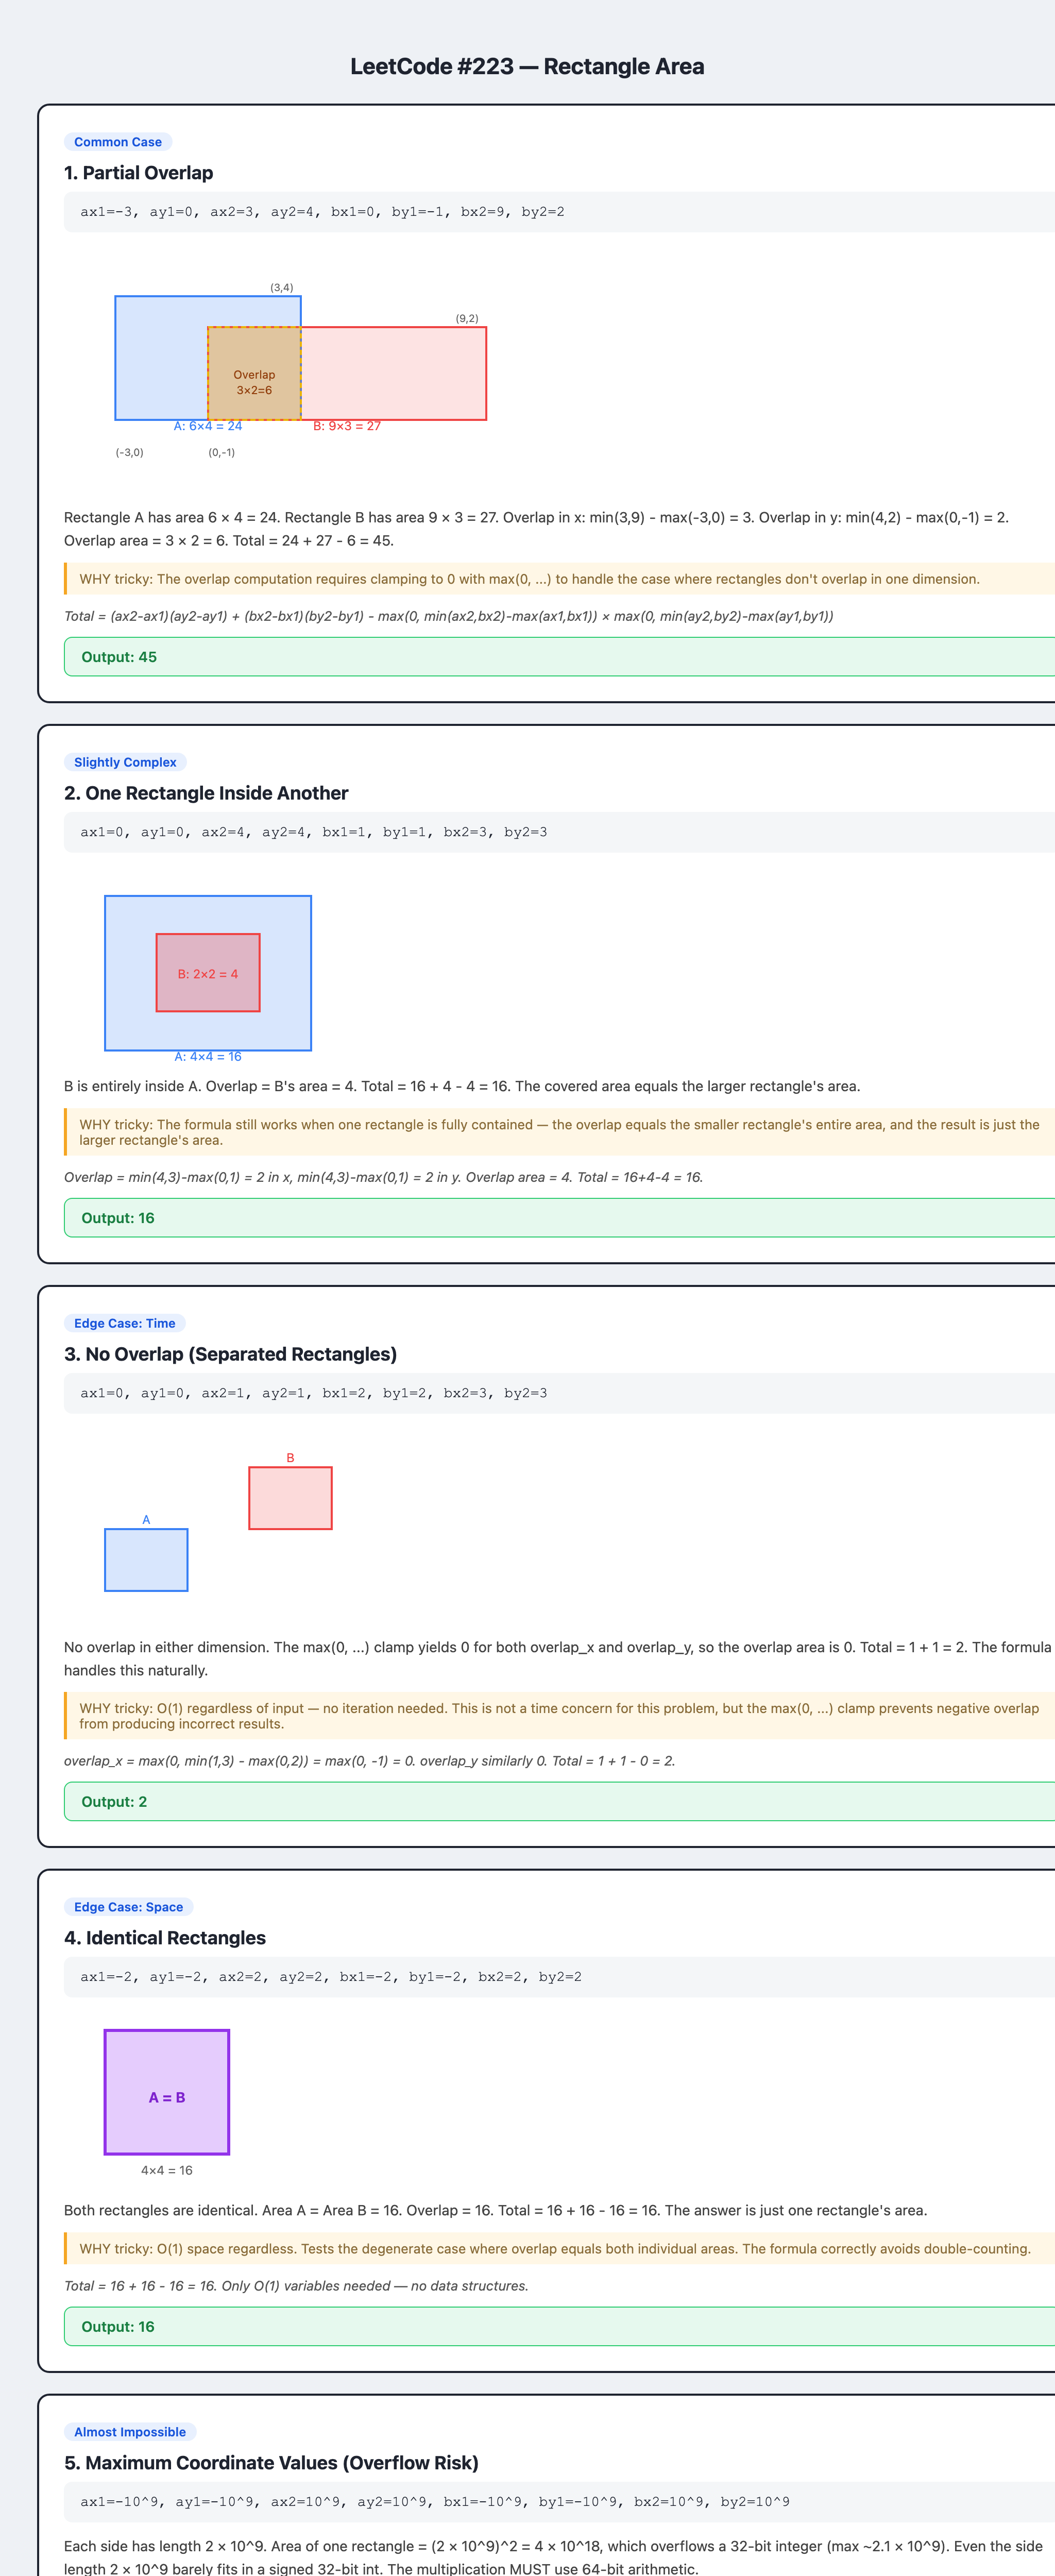